## Import Library

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 

import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
raw_data = pd.read_csv('../data/raw/health_insurance_origin.csv')

In [3]:
# Just for check :o
raw_data.head(2)

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51


## Split Dataset

In [4]:
# This split used in the early satge, for avoid data leackage
# because we will fill the missing value with median and mode
train_data, test_data = train_test_split(raw_data, test_size=0.2, random_state=42)

print('Train data Shape:', train_data.shape)
print('Test data Shape:', test_data.shape)

Train data Shape: (1072, 10)
Test data Shape: (268, 10)


## Preprocessing

### remove unnecessery column

In [5]:
# because Id column is not useful for our model
train_data = train_data.drop(columns=['Id'])
test_data = test_data.drop(columns=['Id'])

### Handle Missing values

In [6]:
train_data.isna().sum()

age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [7]:
test_data.isna().sum()

age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [8]:
# fill the missing value with median and mode
# because for make data more robust outlier and noise
train_data['age'] = train_data['age'].fillna(train_data['age'].median())
train_data['region'] = train_data['region'].fillna(train_data['region'].mode()[0])

In [9]:
# Just for ensure
train_data.isna().sum()

age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

### Feature Engginering

In [10]:
# Grouping ages to make it easier for the model to learn
bins_age = [0, 12, 19, 35, 60, raw_data['age'].max() + 1]
label_age = ['Child', 'Teenager', 'Adult', 'Middle aged', 'Senior']

train_data['age_group'] = pd.cut(train_data['age'], bins=bins_age, labels=label_age)
test_data['age_group'] = pd.cut(test_data['age'], bins=bins_age, labels=label_age)

In [11]:
train_data[['age', 'age_group']].head()

,age,age_group
1148,32.0,Adult
807,51.0,Middle aged
1287,32.0,Adult
590,38.0,Middle aged
1188,37.0,Middle aged


In [12]:
# Grpuing BMI with standard category from WHO
bins_bmi = [0, 18.5, 24.9, 29.9, raw_data['bmi'].max() + 1]
label_bmi = ['Underweight', 'Normal', 'Overweight', 'Obese']

train_data['bmi_category'] = pd.cut(train_data['bmi'], bins=bins_bmi, labels=label_bmi)
test_data['bmi_category'] = pd.cut(test_data['bmi'], bins=bins_bmi, labels=label_bmi)

In [13]:
train_data[['bmi', 'bmi_category']].head()

,bmi,bmi_category
1148,26.7,Overweight
807,25.7,Overweight
1287,39.0,Obese
590,23.4,Normal
1188,28.3,Overweight


In [14]:
# Based on Systolic Blood Pressure(SBP) category for get better result
bins_bp = [0, 119, 139, raw_data['bloodpressure'].max() +1]
label_bp = ['Normal', 'Pre-Hypertension', 'Hypertension']

train_data['bp_status'] = pd.cut(train_data['bloodpressure'], bins=bins_bp, labels=label_bp)
test_data['bp_status'] = pd.cut(test_data['bloodpressure'], bins=bins_bp, labels=label_bp)

In [15]:
train_data[['bloodpressure', 'bp_status']].head()

,bloodpressure,bp_status
1148,115,Normal
807,83,Normal
1287,96,Normal
590,96,Normal
1188,88,Normal


### Encoding

In [16]:
# Mapping binary for simply feature with just 2 category
mapping_binarry = {'yes': 1, 'no': 0, 'male': 1, 'female': 0}
binarry_columns = ['smoker', 'diabetic', 'gender']

# astype(str) & str.lowe() to ensure that data is in correct format 
# and cases sensitive for mapping
for col in binarry_columns:
    train_data[col] = train_data[col].astype(str).str.lower().map(mapping_binarry)
    test_data[col] = test_data[col].astype(str).str.lower().map(mapping_binarry)

In [17]:
# Ordinal mapping because the data have order category
# manual encod for get more control
ordinal_mapping = {
    'age_group': {'Child': 0, 'Teenager': 1, 'Adult': 2, 'Middle aged': 3, 'Senior': 4},
    'bmi_category': {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3},
    'bp_status': {'Normal': 0, 'Pre-Hypertension': 1, 'Hypertension': 2}
}

for col, mapping in ordinal_mapping.items():
    train_data[col] = train_data[col].map(mapping)
    test_data[col] = test_data[col].map(mapping)

In [18]:
# OneHot Encod because the data dont have order category
# drop_first to avoid dummy variable trap
# dtype=int -> to convert boolean to int for we can see the .corr()
train_data = pd.get_dummies(train_data, columns=['region'], prefix='reg', drop_first=True, dtype=int)
test_data = pd.get_dummies(test_data, columns=['region'], prefix='reg', drop_first=True, dtype=int)

## Check data after Feature Engg

In [19]:
train_data.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker,claim,age_group,bmi_category,bp_status,reg_northwest,reg_southeast,reg_southwest
1148,32.0,1,26.7,115,1,1,1,26109.33,2,2,0,1,0,0
807,51.0,0,25.7,83,1,0,0,11454.02,3,2,0,1,0,0
1287,32.0,0,39.0,96,1,0,1,42983.46,2,3,0,1,0,0
590,38.0,0,23.4,96,1,3,0,8252.28,3,1,0,0,0,0
1188,37.0,1,28.3,88,0,3,1,32787.46,3,2,0,1,0,0


In [20]:
# Fast check for missing value after preprocessing
print(train_data.isna().sum().sum())
print(test_data.isna().sum().sum())

0
0


In [21]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 1072 entries, 1148 to 1126
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            1072 non-null   float64 
 1   gender         1072 non-null   int64   
 2   bmi            1072 non-null   float64 
 3   bloodpressure  1072 non-null   int64   
 4   diabetic       1072 non-null   int64   
 5   children       1072 non-null   int64   
 6   smoker         1072 non-null   int64   
 7   claim          1072 non-null   float64 
 8   age_group      1072 non-null   category
 9   bmi_category   1072 non-null   category
 10  bp_status      1072 non-null   category
 11  reg_northwest  1072 non-null   int64   
 12  reg_southeast  1072 non-null   int64   
 13  reg_southwest  1072 non-null   int64   
dtypes: category(3), float64(3), int64(8)
memory usage: 103.7 KB


In [22]:
cols_to_fix = ['diabetic', 'smoker', 'gender', 'age_group', 'bmi_category', 'bp_status']

train_data[cols_to_fix] = train_data[cols_to_fix].astype(int)
test_data[cols_to_fix] = test_data[cols_to_fix].astype(int)

In [23]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 1072 entries, 1148 to 1126
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1072 non-null   float64
 1   gender         1072 non-null   int64  
 2   bmi            1072 non-null   float64
 3   bloodpressure  1072 non-null   int64  
 4   diabetic       1072 non-null   int64  
 5   children       1072 non-null   int64  
 6   smoker         1072 non-null   int64  
 7   claim          1072 non-null   float64
 8   age_group      1072 non-null   int64  
 9   bmi_category   1072 non-null   int64  
 10  bp_status      1072 non-null   int64  
 11  reg_northwest  1072 non-null   int64  
 12  reg_southeast  1072 non-null   int64  
 13  reg_southwest  1072 non-null   int64  
dtypes: float64(3), int64(11)
memory usage: 125.6 KB


### Check Correlation 

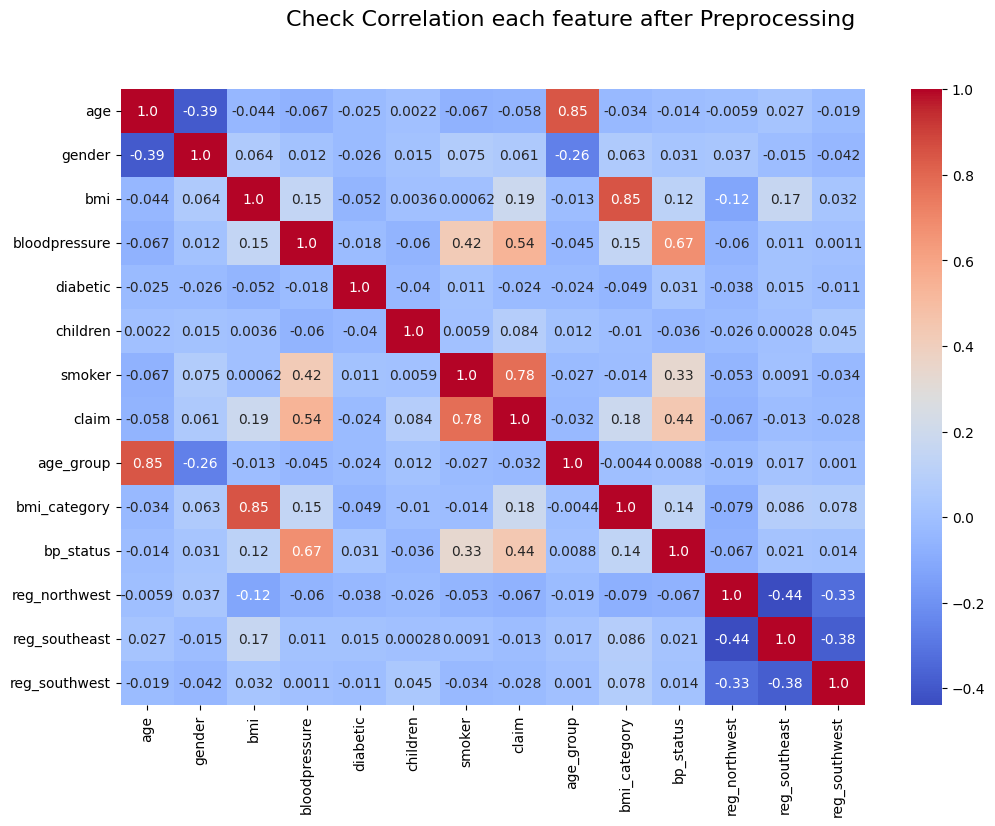

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm', fmt='.2')
plt.suptitle('Check Correlation each feature after Preprocessing', fontsize=16)
plt.show()

In [25]:
target_corr = train_data.corr()['claim'].sort_values(ascending=False)

print('Corr each feature between Claim:')
display(target_corr)

Corr each feature between Claim:


claim            1.000000
smoker           0.777491
bloodpressure    0.536728
bp_status        0.438985
bmi              0.188388
bmi_category     0.184486
children         0.083779
gender           0.060600
reg_southeast   -0.013410
diabetic        -0.024398
reg_southwest   -0.028076
age_group       -0.031700
age             -0.057939
reg_northwest   -0.067305
Name: claim, dtype: float64

## Save the Data

In [28]:
# Save to .pkl(pickle) for make sure dtype not change when we load data for modelling
train_data.to_pickle('../data/preprocess/train_data.pkl')
test_data.to_pickle('../data/preprocess/test_data.pkl')